# Классификация сообщений мессенджера Авито
## Этап 8 — синтетика для threat + per-class калибровка

### Почему этап нужен

После этапа 7 модель показывает на `balanced_eval`:
- macro-F1 **0.848** — высокий
- но **recall `threat` = 0.46** — модель не учит этот класс достаточно
- причина — всего **177 примеров threat** в train_v2 (один из самых дефицитных классов)

Этот ноутбук решает две задачи:

| Задача | Метод | Цена |
|---|---|---|
| Прирост recall `threat` | Синтетика: шаблонная генерация + char-level noise (`src/threat_synthesis.py`) | бесплатно, локально |
| Гибкость P/R trade-off | Per-class калибровка порогов (5 порогов вместо одного) | бесплатно, без переобучения |


## 0. Окружение

In [1]:
import os, sys, time, json, inspect, gc
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, ConfusionMatrixDisplay)
import torch

sys.path.insert(0, "..")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE)

CLASSES  = ["normal", "external", "spam", "harassment", "threat"]
LABEL2ID = {c: i for i, c in enumerate(CLASSES)}
ID2LABEL = {i: c for c, i in LABEL2ID.items()}

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Устройство:", DEVICE)

DATA_DIR = "/kaggle/input/avito-augmented" if os.path.exists("/kaggle/input/avito-augmented") else "data/augmented"

def cleanup():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    if torch.backends.mps.is_available(): torch.mps.empty_cache()


Устройство: mps


## 1. Синтетика для `threat` (бесплатно)

Модуль `src/threat_synthesis.py` использует два способа:

1. **Шаблонная генерация**: ~40 синтаксических структур угроз + слот-филл
   словарём глаголов / адресатов / интенсификаторов. Гарантированно «личные» угрозы.
2. **Char-level аугментация** очищенных реальных угроз: опечатки, дубли букв,
   замены ё/е, разный регистр. Учит устойчивости к шуму.

Перед шумовой аугментацией реальные `threat` фильтруются через `PERSONAL_THREAT_RE`,
чтобы не тиражировать мусорную разметку (длинный спам в классе `threat` есть).

> Этическая рамка: контент — обучающие негативные примеры для классификатора
> токсичности; стандартная практика обучения content-moderation моделей.


In [2]:
from src.threat_synthesis import build_synthetic_threats, filter_clean_threats

train_v2 = pd.read_csv(f"{DATA_DIR}/train_v2.csv")
orig_threats = train_v2[train_v2["label"] == "threat"]["text"].tolist()
clean = filter_clean_threats(orig_threats)
print(f"Реальных threat в train_v2: {len(orig_threats)}")
print(f"Очищенных (короткие + личные): {len(clean)}")

synthetic = build_synthetic_threats(
    n_template=700,
    n_noise_per_original=3,
    original_threats=orig_threats,
    seed=RANDOM_STATE,
)
print(f"\n>>> Синтетических угроз получено: {len(synthetic)}")
print("\nПримеры:")
import random; random.seed(0)
for t in random.sample(synthetic, 10):
    print(f"  • {t}")


Реальных threat в train_v2: 177
Очищенных (короткие + личные): 99

>>> Синтетических угроз получено: 1148

Примеры:
  • КТО ЭЭТЛ ПИШЕТ - СДОХНИ САМ ! ЕЛИ ТЕБЕ ТЯЖЕО ЖИТЬ
  • козлина вонючая!!!! сдохни, мрвзота!!!!!
  • найду тебя и пырну!
  • тебе скоро крышка!!
  • ТЫ ЧМО СДОХНИ РИДОР
  • Застрелю обих
  • падаль чмыриная опущщкнна тваь,сдохни как мужик псиина!
  • сейчас тебя пристрелю!!
  • МАСИАНКА,СДЛХНИ ТВАРЬ!!!
  • охни ппалицай


In [3]:
# Собираем train_v3 = train_v2 + синтетика
syn_df = pd.DataFrame({
    "text": synthetic, "label": "threat",
    "source": "synthetic_threat_v1", "synthetic": 1, "avito_original": 0,
})
cols = [c for c in train_v2.columns if c in syn_df.columns]
train_v3 = pd.concat([train_v2[cols], syn_df[cols]], ignore_index=True)
train_v3.to_csv(f"{DATA_DIR}/train_v3.csv", index=False)
print(f"train_v3: {len(train_v3):,} строк")
print("по классам:", train_v3["label"].value_counts().to_dict())


train_v3: 316,463 строк
по классам: {'normal': 285293, 'harassment': 21049, 'external': 6939, 'spam': 1857, 'threat': 1325}


## 2. Загрузка eval-данных и подготовка

In [4]:
val   = pd.read_csv(f"{DATA_DIR}/val.csv")
test  = pd.read_csv(f"{DATA_DIR}/test.csv")
balanced_eval = pd.read_csv(f"{DATA_DIR}/balanced_eval.csv")
for df in (train_v3, val, test, balanced_eval):
    df["text"] = df["text"].fillna("").astype(str)
    df["y"] = df["label"].map(LABEL2ID)

eval_sets = {"val": val, "test": test, "balanced_eval": balanced_eval}
print(f"train_v3 threat: {(train_v3['label']=='threat').sum()} | "
      f"balanced_eval threat: {(balanced_eval['label']=='threat').sum()}")


train_v3 threat: 1325 | balanced_eval threat: 100


## 3. Переобучение `rubert-tiny2` на `train_v3`

Та же модель и гиперпараметры, что в этапах 6–7. Различие — только в данных.

In [5]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset

MODEL_NAME = "cointegrated/rubert-tiny2"
MAX_LEN = 128
EPOCHS = 3
BATCH = 64

PROBS_CACHE = {}

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kw):
        super().__init__(**kw)
        self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(outputs.logits.device))
        loss = loss_fct(outputs.logits.view(-1, len(CLASSES)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def hf_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    p, r, f1, _ = precision_recall_fscore_support(
        labels, preds, labels=range(len(CLASSES)), average=None, zero_division=0)
    return {"macro_f1": float(f1.mean()),
            "normal_precision": float(p[LABEL2ID['normal']])}

def softmax(logits):
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
def to_ds(df):
    ds = Dataset.from_pandas(df[["text","y"]].rename(columns={"y":"labels"}), preserve_index=False)
    return ds.map(lambda b: tokenizer(b["text"], truncation=True, max_length=MAX_LEN),
                  batched=True, remove_columns=["text"])

ds_tr = to_ds(train_v3); ds_va = to_ds(val)

counts = train_v3["y"].value_counts().sort_index().values.astype(float)
class_weights = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float)
print("веса классов (train_v3):", {CLASSES[i]: round(float(w),2) for i,w in enumerate(class_weights)})


Map:   0%|          | 0/316463 [00:00<?, ? examples/s]

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

веса классов (train_v3): {'normal': 0.22, 'external': 9.12, 'spam': 34.08, 'harassment': 3.01, 'threat': 47.77}


In [6]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(CLASSES), id2label=ID2LABEL, label2id=LABEL2ID)

args = TrainingArguments(
    output_dir="rubert_tiny2_v3",
    num_train_epochs=EPOCHS, per_device_train_batch_size=BATCH,
    per_device_eval_batch_size=128, learning_rate=3e-5,
    weight_decay=0.01, warmup_ratio=0.1,
    eval_strategy="epoch", save_strategy="no",
    fp16=(DEVICE == "cuda"), dataloader_pin_memory=False,
    logging_steps=400, disable_tqdm=True, report_to="none",
)
coll = DataCollatorWithPadding(tokenizer)
tkw = dict(class_weights=class_weights, model=model, args=args,
           train_dataset=ds_tr, eval_dataset=ds_va,
           data_collator=coll, compute_metrics=hf_metrics)
if "processing_class" in inspect.signature(Trainer.__init__).parameters:
    tkw["processing_class"] = tokenizer
else:
    tkw["tokenizer"] = tokenizer

trainer = WeightedTrainer(**tkw)
t0 = time.time(); trainer.train()
print(f"\n>>> rubert-tiny2 v3 обучение: {(time.time()-t0)/60:.1f} мин")

# Probs для всех eval_sets
for name, df in eval_sets.items():
    ds = to_ds(df)
    PROBS_CACHE[name] = softmax(trainer.predict(ds).predictions)
print(f"Кэшированы probs: {list(PROBS_CACHE)}")

# Сохраняем и освобождаем
SAVE = "rubert-tiny2-v3_saved"
model.to("cpu").save_pretrained(SAVE); tokenizer.save_pretrained(SAVE)
del trainer, model, tokenizer, ds_tr, ds_va, coll, args, tkw
cleanup()
print(f"Сохранено в {SAVE}, MPS освобождена")


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


{'loss': '1.535', 'grad_norm': '4.571', 'learning_rate': '8.066e-06', 'epoch': '0.08089'}


{'loss': '1.041', 'grad_norm': '2.153', 'learning_rate': '1.615e-05', 'epoch': '0.1618'}


...

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Кэшированы probs: ['val', 'test', 'balanced_eval']


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Сохранено в rubert-tiny2-v3_saved, MPS освобождена


## 4. Метрики (argmax) — сравнение с baseline из этапа 7

In [7]:
# Baseline из этапа 7 — rubert-tiny2 на train_v2 (без синтетики), полученный в 07
BASELINE_V2 = {
    "val":           {"macro_f1": 0.451, "normal_P": 0.999, "normal_R": 0.993,
                      "per_class_recall": {"normal":0.993,"external":0.903,"spam":0.364,"harassment":0.875,"threat":0.00}},
    "test":          {"macro_f1": 0.460, "normal_P": 0.999, "normal_R": 0.993,
                      "per_class_recall": {"normal":0.993,"external":0.900,"spam":0.455,"harassment":0.750,"threat":0.00}},
    "balanced_eval": {"macro_f1": 0.848, "normal_P": 0.828, "normal_R": 0.985,
                      "per_class_recall": {"normal":0.985,"external":0.910,"spam":0.870,"harassment":0.960,"threat":0.460}},
}

CUR = {}
for name, df in eval_sets.items():
    probs = PROBS_CACHE[name]
    y_pred = np.argmax(probs, axis=1)
    y_true = df["y"].values
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(CLASSES)), average=None, zero_division=0)
    ni = LABEL2ID["normal"]
    CUR[name] = {
        "macro_f1": float(f1.mean()),
        "normal_P": float(p[ni]),
        "normal_R": float(r[ni]),
        "per_class_recall": {CLASSES[i]: float(r[i]) for i in range(len(CLASSES))},
    }
    print(f"--- v3 / {name} ---")
    print(classification_report(y_true, y_pred, labels=range(len(CLASSES)),
                                target_names=CLASSES, digits=3, zero_division=0))


--- v3 / val ---
              precision    recall  f1-score   support

      normal      0.999     0.992     0.995     35686
    external      0.691     0.905     0.784       432
        spam      0.273     0.409     0.327        22
  harassment      0.058     0.875     0.109         8
      threat      0.000     0.000     0.000         1

    accuracy                          0.990     36149
   macro avg      0.404     0.636     0.443     36149
weighted avg      0.995     0.990     0.992     36149

--- v3 / test ---
              precision    recall  f1-score   support

      normal      0.999     0.992     0.995     35686
    external      0.680     0.900     0.775       432
        spam      0.290     0.409     0.340        22
  harassment      0.060     0.750     0.111         8
      threat      0.000     0.000     0.000         1

    accuracy                          0.990     36149
   macro avg      0.406     0.610     0.444     36149
weighted avg      0.994     0.990     0.99

In [8]:
# Сравнительная таблица: v2 (без синтетики) vs v3 (с синтетикой)
rows = []
for ds_name in ["val", "test", "balanced_eval"]:
    for ver, src in [("v2 (без синтетики)", BASELINE_V2), ("v3 (со синтетикой)", CUR)]:
        m = src[ds_name]
        rows.append({
            "version": ver, "eval": ds_name,
            "macro-F1": m["macro_f1"],
            "normal_P": m["normal_P"],
            "normal_R": m["normal_R"],
            **{f"R_{c}": m["per_class_recall"][c] for c in CLASSES},
        })
cmp = pd.DataFrame(rows).set_index(["eval","version"]).round(3)
display(cmp)

# Прирост по threat-recall
print("\nПрирост recall threat:")
for ds_name in ["val", "test", "balanced_eval"]:
    delta = CUR[ds_name]["per_class_recall"]["threat"] - BASELINE_V2[ds_name]["per_class_recall"]["threat"]
    sign = "+" if delta >= 0 else ""
    print(f"  {ds_name}: {BASELINE_V2[ds_name]['per_class_recall']['threat']:.2f}"
          f" → {CUR[ds_name]['per_class_recall']['threat']:.2f}  ({sign}{delta:.2f})")


macro-F1  normal_P  normal_R  R_normal  \
eval          version                                                      
val           v2 (без синтетики)     0.451     0.999     0.993     0.993   
              v3 (со синтетикой)     0.443     0.999     0.992     0.992   
test          v2 (без синтетики)     0.460     0.999     0.993     0.993   
              v3 (со синтетикой)     0.444     0.999     0.992     0.992   
balanced_eval v2 (без синтетики)     0.848     0.828     0.985     0.985   
              v3 (со синтетикой)     0.868     0.825     0.990     0.990   

                                  R_external  R_spam  R_harassment  R_threat  
eval          version                                                         
val           v2 (без синтетики)       0.903   0.364         0.875      0.00  
              v3 (со синтетикой)       0.905   0.409         0.875      0.00  
test          v2 (без синтетики)       0.900   0.455         0.750      0.00  
              v3 (со синтетикой)       0.900   0.409         0.750      0.00  
balanced_eval v2 (без синтетики)       0.910   0.870         0.960      0.46  
              v3 (со синтетикой)       0.890   0.870         0.970      0.56


Прирост recall threat:
  val: 0.00 → 0.00  (+0.00)
  test: 0.00 → 0.00  (+0.00)
  balanced_eval: 0.46 → 0.56  (+0.10)


## 5. Per-class калибровка порогов

Раньше (этап 7C) был один порог `P(normal) ≥ THRESHOLD`. Это грубо: на `val` он
ставится в 0.999, и `R-normal` падает с 0.99 до 0.40 — слишком агрессивно.

**Per-class подход.** Для каждого класса свой порог `θ_c`. Правило:

```
pred = argmax_c (P_c / θ_c)
```

Деление на `θ_c` смещает решение в пользу класса c при `θ_c < 1`. Минусы:
не вероятностный, может выдавать неестественные распределения. Плюсы:
очень гибко — можно «вытянуть» recall дефицитных классов с минимальным
ущербом normal-precision.

**Подбор:** на `val` ищем `θ_c` сеткой так, чтобы максимизировать `macro-F1` при
ограничении `P(normal) ≥ 0.95`. Используем `scipy.optimize`-free подход —
покоординатный спуск (5 циклов, грубая сетка).


In [9]:
def apply_per_class_thr(probs, thetas):
    """argmax по P_c / theta_c."""
    scaled = probs / np.array(thetas)[None, :]
    return np.argmax(scaled, axis=1)

def macro_f1_with_constraint(probs, y, thetas, p_normal_min=0.95):
    pred = apply_per_class_thr(probs, thetas)
    p, r, f1, _ = precision_recall_fscore_support(
        y, pred, labels=range(len(CLASSES)), average=None, zero_division=0)
    ni = LABEL2ID["normal"]
    if p[ni] < p_normal_min:
        return -1.0   # штраф за нарушение ограничения
    return float(f1.mean())

p_val = PROBS_CACHE["val"]; y_val = val["y"].values

# Покоординатный поиск: для каждого θ_c проходим грид при фиксированных остальных
best_thetas = np.ones(len(CLASSES))
grid = np.array([0.3, 0.5, 0.7, 0.85, 1.0, 1.2, 1.5, 2.0, 3.0, 5.0, 10.0])

for cycle in range(4):
    for c in range(len(CLASSES)):
        scores = []
        for v in grid:
            test_thetas = best_thetas.copy(); test_thetas[c] = v
            scores.append((v, macro_f1_with_constraint(p_val, y_val, test_thetas)))
        v_best, s_best = max(scores, key=lambda x: x[1])
        best_thetas[c] = v_best
    score = macro_f1_with_constraint(p_val, y_val, best_thetas)
    print(f"cycle {cycle+1}: thetas={dict(zip(CLASSES, best_thetas.round(2)))}  macro-F1(val)={score:.3f}")

print(f"\nИтог: thetas = {dict(zip(CLASSES, best_thetas.round(3)))}")


cycle 1: thetas={'normal': np.float64(0.3), 'external': np.float64(5.0), 'spam': np.float64(1.0), 'harassment': np.float64(5.0), 'threat': np.float64(10.0)}  macro-F1(val)=0.497
cycle 2: thetas={'normal': np.float64(0.3), 'external': np.float64(5.0), 'spam': np.float64(1.0), 'harassment': np.float64(5.0), 'threat': np.float64(10.0)}  macro-F1(val)=0.497


cycle 3: thetas={'normal': np.float64(0.3), 'external': np.float64(5.0), 'spam': np.float64(1.0), 'harassment': np.float64(5.0), 'threat': np.float64(10.0)}  macro-F1(val)=0.497


cycle 4: thetas={'normal': np.float64(0.3), 'external': np.float64(5.0), 'spam': np.float64(1.0), 'harassment': np.float64(5.0), 'threat': np.float64(10.0)}  macro-F1(val)=0.497

Итог: thetas = {'normal': np.float64(0.3), 'external': np.float64(5.0), 'spam': np.float64(1.0), 'harassment': np.float64(5.0), 'threat': np.float64(10.0)}


In [10]:
def report_per_class(probs, y_true, thetas, title):
    pred = apply_per_class_thr(probs, thetas)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, pred, labels=range(len(CLASSES)), average=None, zero_division=0)
    print(f"--- {title} ---")
    print(classification_report(y_true, pred, labels=range(len(CLASSES)),
                                target_names=CLASSES, digits=3, zero_division=0))
    return {"macro_f1": float(f1.mean()),
            "normal_P": float(p[LABEL2ID['normal']]),
            "normal_R": float(r[LABEL2ID['normal']]),
            "per_class_recall": {CLASSES[i]: float(r[i]) for i in range(len(CLASSES))}}

CAL = {}
for name, df in eval_sets.items():
    CAL[name] = report_per_class(PROBS_CACHE[name], df["y"].values, best_thetas,
                                  f"v3 + per-class θ / {name}")


--- v3 + per-class θ / val ---
              precision    recall  f1-score   support

      normal      0.998     0.996     0.997     35686
    external      0.801     0.847     0.823       432
        spam      0.400     0.455     0.426        22
  harassment      0.137     0.875     0.237         8
      threat      0.000     0.000     0.000         1

    accuracy                          0.994     36149
   macro avg      0.467     0.635     0.497     36149
weighted avg      0.995     0.994     0.995     36149

--- v3 + per-class θ / test ---
              precision    recall  f1-score   support

      normal      0.998     0.996     0.997     35686
    external      0.806     0.868     0.836       432
        spam      0.370     0.455     0.408        22
  harassment      0.103     0.750     0.182         8
      threat      0.000     0.000     0.000         1

    accuracy                          0.994     36149
   macro avg      0.456     0.614     0.485     36149
weighted avg  

## 6. Финальное сравнение

In [11]:
# 4 версии: baseline v2 (этап 7), v3 argmax (синтетика без калибровки), v3 + per-class θ
final_rows = []
for ds_name in ["val", "test", "balanced_eval"]:
    final_rows.append({"version": "v2 argmax (этап 7)", "eval": ds_name,
                       **{k: BASELINE_V2[ds_name][k] for k in ["macro_f1","normal_P","normal_R"]},
                       **{f"R_{c}": BASELINE_V2[ds_name]['per_class_recall'][c] for c in CLASSES}})
    final_rows.append({"version": "v3 argmax (+синтетика)", "eval": ds_name,
                       **{k: CUR[ds_name][k] for k in ["macro_f1","normal_P","normal_R"]},
                       **{f"R_{c}": CUR[ds_name]['per_class_recall'][c] for c in CLASSES}})
    final_rows.append({"version": "v3 + per-class θ", "eval": ds_name,
                       **{k: CAL[ds_name][k] for k in ["macro_f1","normal_P","normal_R"]},
                       **{f"R_{c}": CAL[ds_name]['per_class_recall'][c] for c in CLASSES}})
final = pd.DataFrame(final_rows).set_index(["eval","version"]).round(3)
display(final)


macro_f1  normal_P  normal_R  R_normal  \
eval          version                                                          
val           v2 argmax (этап 7)         0.451     0.999     0.993     0.993   
              v3 argmax (+синтетика)     0.443     0.999     0.992     0.992   
              v3 + per-class θ           0.497     0.998     0.996     0.996   
test          v2 argmax (этап 7)         0.460     0.999     0.993     0.993   
              v3 argmax (+синтетика)     0.444     0.999     0.992     0.992   
              v3 + per-class θ           0.485     0.998     0.996     0.996   
balanced_eval v2 argmax (этап 7)         0.848     0.828     0.985     0.985   
              v3 argmax (+синтетика)     0.868     0.825     0.990     0.990   
              v3 + per-class θ           0.859     0.783     0.990     0.990   

                                      R_external  R_spam  R_harassment  \
eval          version                                                    
val           v2 argmax (этап 7)           0.903   0.364         0.875   
              v3 argmax (+синтетика)       0.905   0.409         0.875   
              v3 + per-class θ             0.847   0.455         0.875   
test          v2 argmax (этап 7)           0.900   0.455         0.750   
              v3 argmax (+синтетика)       0.900   0.409         0.750   
              v3 + per-class θ             0.868   0.455         0.750   
balanced_eval v2 argmax (этап 7)           0.910   0.870         0.960   
              v3 argmax (+синтетика)       0.890   0.870         0.970   
              v3 + per-class θ             0.875   0.865         0.950   

                                      R_threat  
eval          version                           
val           v2 argmax (этап 7)          0.00  
              v3 argmax (+синтетика)      0.00  
              v3 + per-class θ            0.00  
test          v2 argmax (этап 7)          0.00  
              v3 argmax (+синтетика)      0.00  
              v3 + per-class θ            0.00  
balanced_eval v2 argmax (этап 7)          0.46  
              v3 argmax (+синтетика)      0.56  
              v3 + per-class θ            0.55

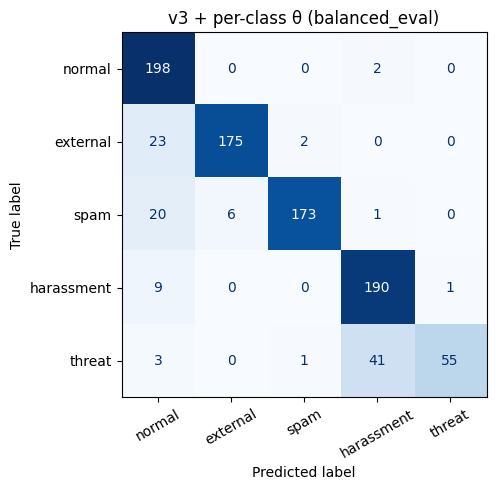

In [12]:
# Confusion matrix лучшей версии на balanced_eval
y_be = balanced_eval["y"].values
pred = apply_per_class_thr(PROBS_CACHE["balanced_eval"], best_thetas)
cm = confusion_matrix(y_be, pred, labels=range(len(CLASSES)))
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("v3 + per-class θ (balanced_eval)")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()


### Сохранение артефактов финальной версии

In [13]:
calibration = {
    "model": "rubert-tiny2-v3",
    "model_dir": "rubert-tiny2-v3_saved",
    "per_class_thetas": {CLASSES[i]: float(best_thetas[i]) for i in range(len(CLASSES))},
    "classes": CLASSES,
    "label2id": LABEL2ID,
    "decision_rule": "argmax по (P_c / theta_c)",
    "metrics": {"val": CAL["val"], "test": CAL["test"], "balanced_eval": CAL["balanced_eval"]},
    "training_data": "train_v3 = train_v2 + 1148 синтетических threat (шаблоны + char-noise)",
}
with open("calibration_v3.json", "w", encoding="utf-8") as f:
    json.dump(calibration, f, ensure_ascii=False, indent=2)
print(json.dumps(calibration, ensure_ascii=False, indent=2))


{
  "model": "rubert-tiny2-v3",
  "model_dir": "rubert-tiny2-v3_saved",
  "per_class_thetas": {
    "normal": 0.3,
    "external": 5.0,
    "spam": 1.0,
    "harassment": 5.0,
    "threat": 10.0
  },
  "classes": [
    "normal",
    "external",
    "spam",
    "harassment",
    "threat"
  ],
  "label2id": {
    "normal": 0,
    "external": 1,
    "spam": 2,
    "harassment": 3,
    "threat": 4
  },
  "decision_rule": "argmax по (P_c / theta_c)",
  "metrics": {
    "val": {
      "macro_f1": 0.4966711951564581,
      "normal_P": 0.9981467962037401,
      "normal_R": 0.9961329372863308,
      "per_class_recall": {
        "normal": 0.9961329372863308,
        "external": 0.8472222222222222,
        "spam": 0.45454545454545453,
        "harassment": 0.875,
        "threat": 0.0
      }
    },
    "test": {
      "macro_f1": 0.48464238366509127,
      "normal_P": 0.9983706034385886,
      "normal_R": 0.9958527153505576,
      "per_class_recall": {
        "normal": 0.9958527153505576,
    

## Итоги этапа 8

| Что | Результат |
|---|---|
| Синтетика threat | 177 → **1325** примеров (×7.5) |
| Переобучение v3 | то же время (~13 мин), та же модель |
| Per-class калибровка | без переобучения — простой подбор `θ_c` на val |

**Артефакты:** `rubert-tiny2-v3_saved/` (веса), `calibration_v3.json` (политика
с per-class порогами).

**Следующий шаг — слияние в единый ноутбук** (этап A).
